In [273]:
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

In [274]:
df = pd.read_csv("hepatitis_csv.csv")

In [275]:
df.head()

,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,class
0,30,male,False,False,False,False,False,False,False,False,False,False,False,1.0,85.0,18.0,4.0,NaN,False,live
1,50,female,False,False,True,False,False,False,False,False,False,False,False,0.9,135.0,42.0,3.5,NaN,False,live
2,78,female,True,False,True,False,False,True,False,False,False,False,False,0.7,96.0,32.0,4.0,NaN,False,live
3,31,female,NaN,True,False,False,False,True,False,False,False,False,False,0.7,46.0,52.0,4.0,80.0,False,live
4,34,female,True,False,False,False,False,True,False,False,False,False,False,1.0,NaN,200.0,4.0,NaN,False,live


In [276]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              155 non-null    int64  
 1   sex              155 non-null    str    
 2   steroid          154 non-null    object 
 3   antivirals       155 non-null    bool   
 4   fatigue          154 non-null    object 
 5   malaise          154 non-null    object 
 6   anorexia         154 non-null    object 
 7   liver_big        145 non-null    object 
 8   liver_firm       144 non-null    object 
 9   spleen_palpable  150 non-null    object 
 10  spiders          150 non-null    object 
 11  ascites          150 non-null    object 
 12  varices          150 non-null    object 
 13  bilirubin        149 non-null    float64
 14  alk_phosphate    126 non-null    float64
 15  sgot             151 non-null    float64
 16  albumin          139 non-null    float64
 17  protime          88 non-nul

In [277]:
numeric_cols = df.select_dtypes(include = ['int64','float64']).columns
print(numeric_cols)

Index(['age', 'bilirubin', 'alk_phosphate', 'sgot', 'albumin', 'protime'], dtype='str')


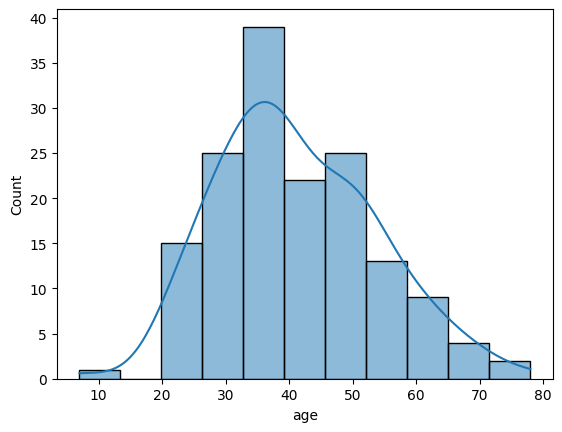

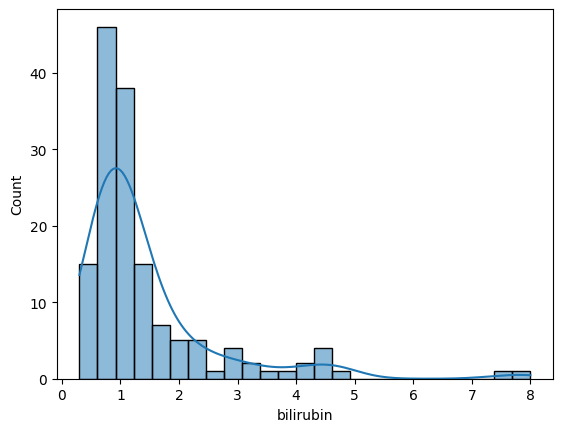

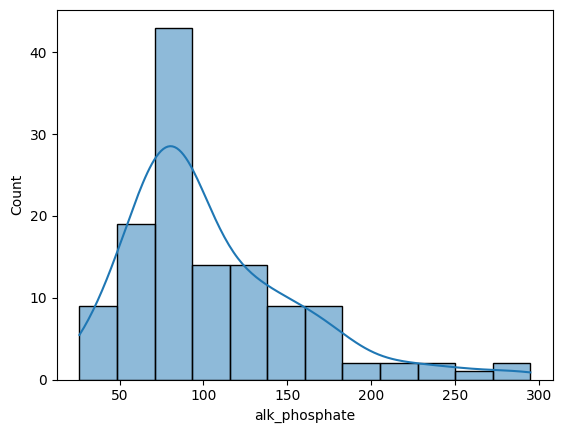

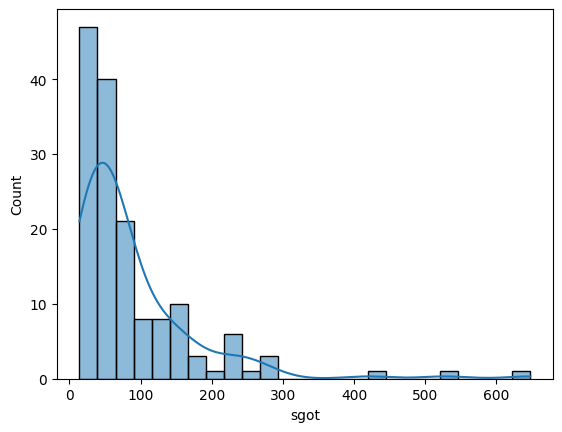

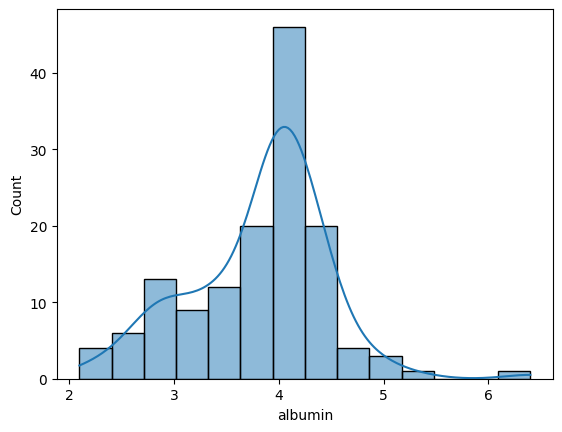

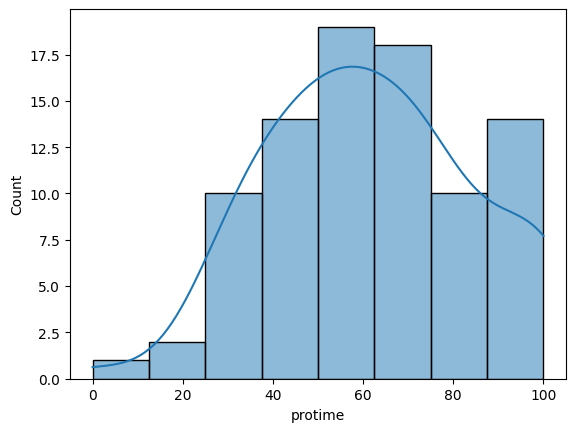

In [278]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde = True)
    plt.show()

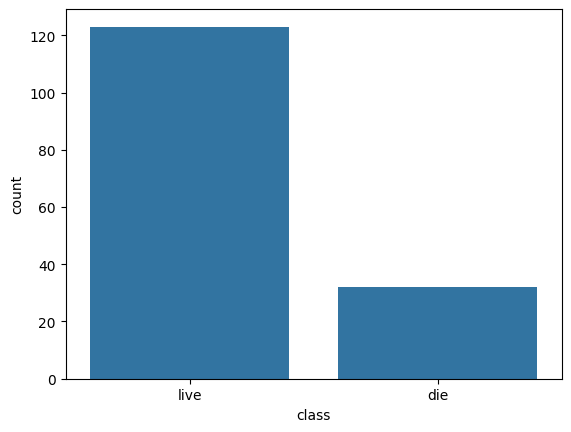

In [279]:
sns.countplot(x='class', data=df)
plt.show()

In [280]:
df.isnull().sum() / len(df) * 100

age                 0.000000
sex                 0.000000
steroid             0.645161
antivirals          0.000000
fatigue             0.645161
malaise             0.645161
anorexia            0.645161
liver_big           6.451613
liver_firm          7.096774
spleen_palpable     3.225806
spiders             3.225806
ascites             3.225806
varices             3.225806
bilirubin           3.870968
alk_phosphate      18.709677
sgot                2.580645
albumin            10.322581
protime            43.225806
histology           0.000000
class               0.000000
dtype: float64

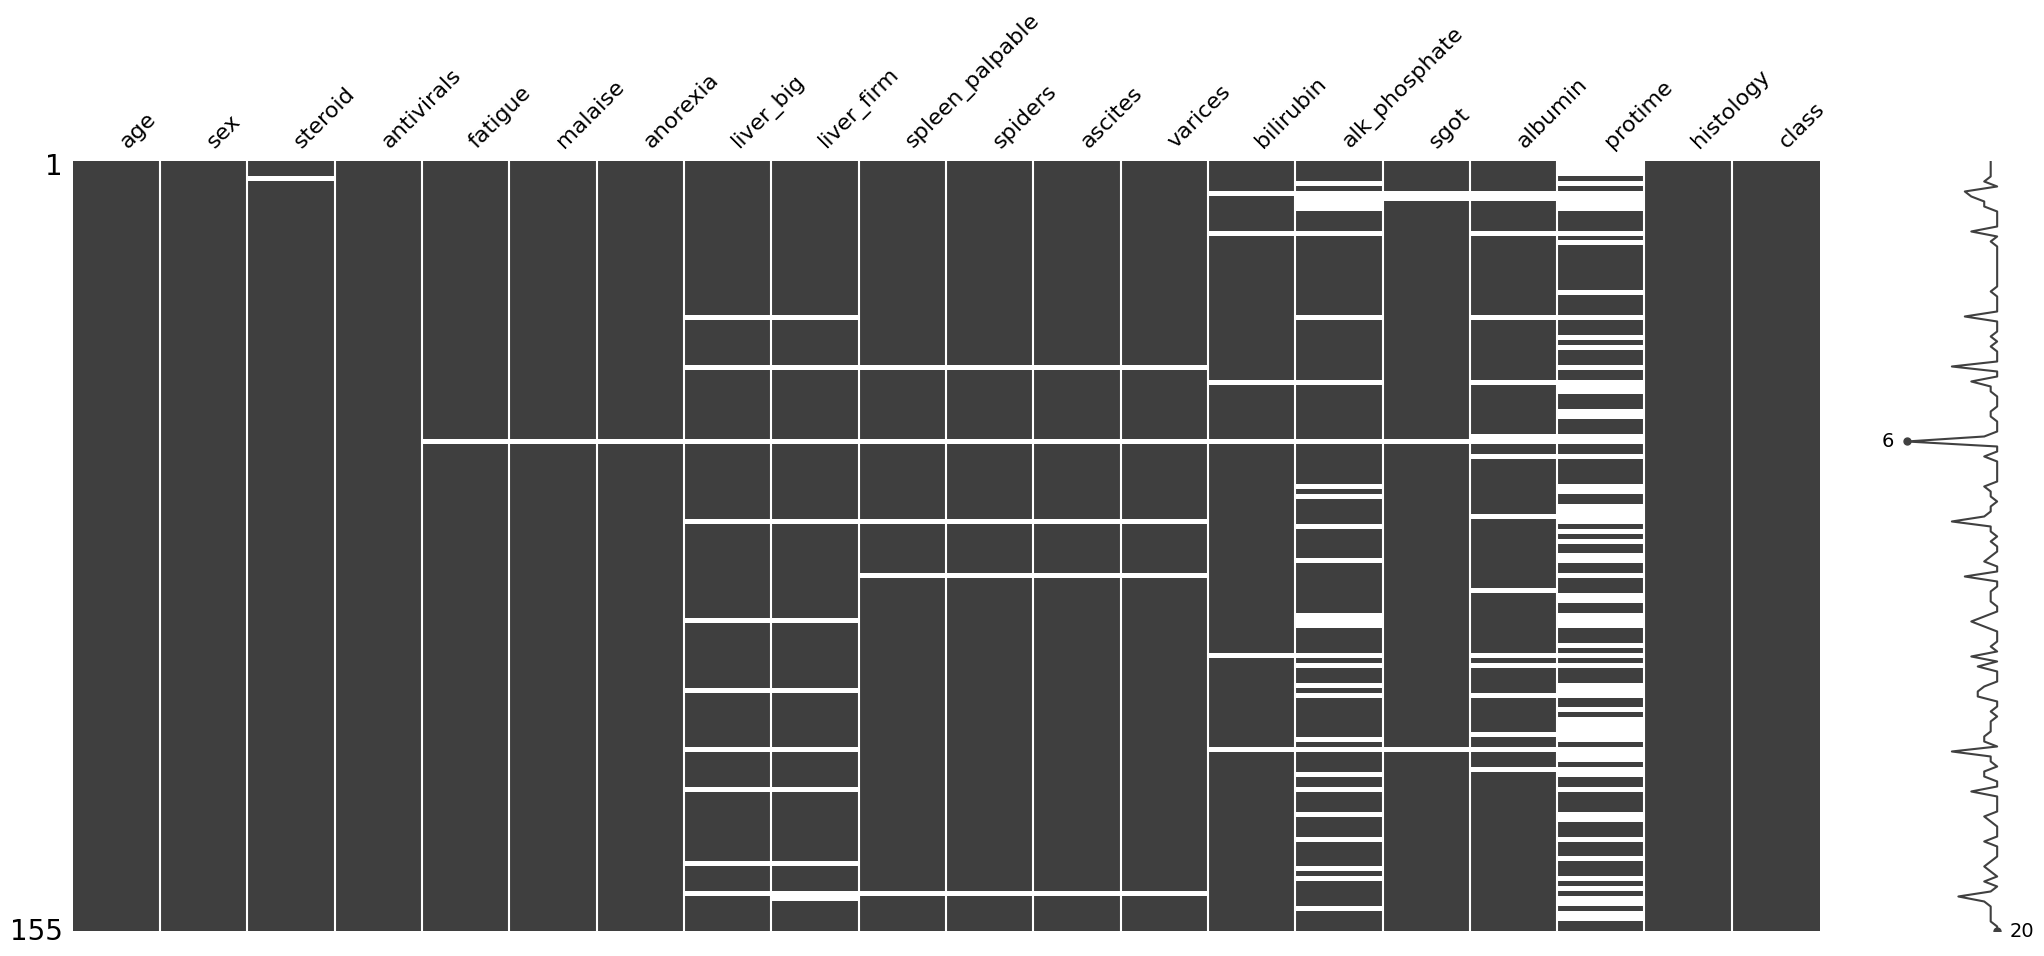

In [281]:
msno.matrix(df)
plt.show()

In [282]:
df_1 = df.drop(columns= 'protime').copy()

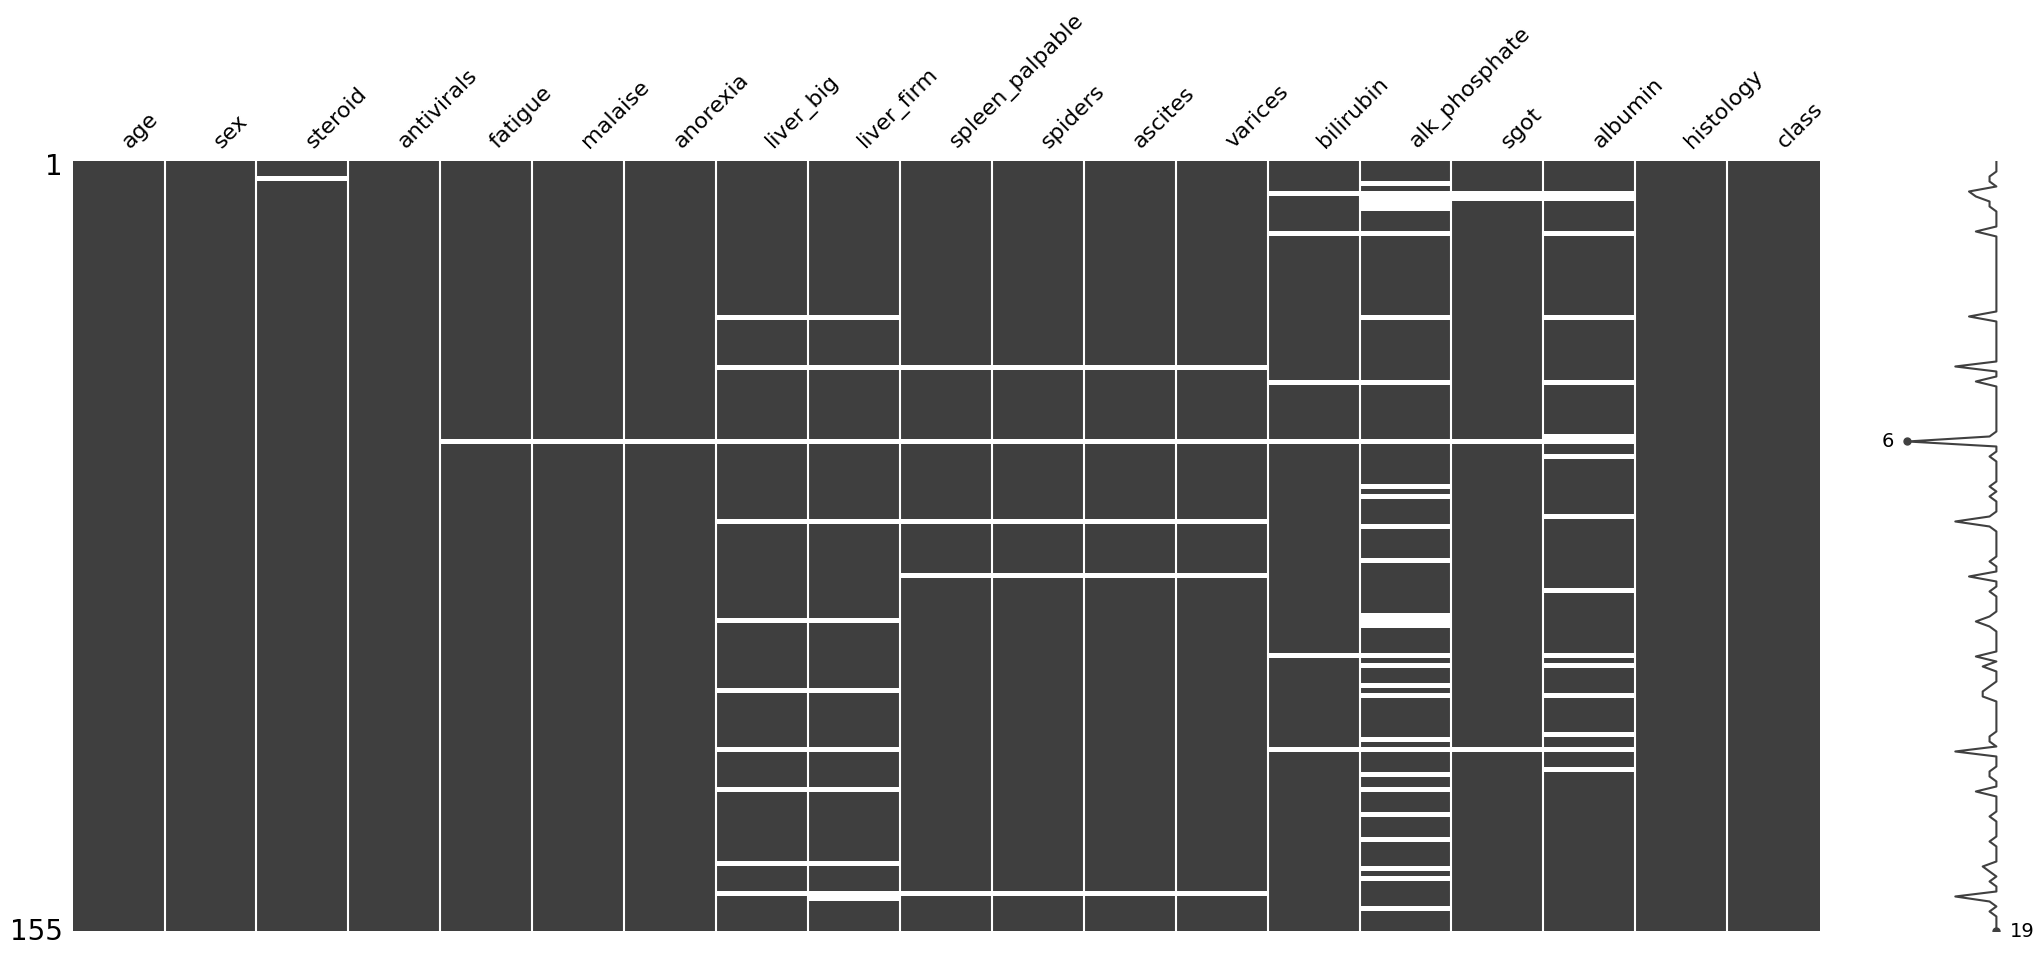

In [283]:
msno.matrix(df_1)
plt.show()

In [284]:
df_1['steroid'] = df_1['steroid'].fillna(df_1['steroid'].mode()[0])
df_1['fatigue'] = df_1['fatigue'].fillna(df_1['fatigue'].mode()[0])
df_1['malaise'] = df_1['malaise'].fillna(df_1['malaise'].mode()[0])
df_1['anorexia'] = df_1['anorexia'].fillna(df_1['anorexia'].mode()[0])
df_1['liver_big'] = df_1['liver_big'].fillna(df_1['liver_big'].mode()[0])
df_1['liver_firm'] = df_1['liver_firm'].fillna(df_1['liver_firm'].mode()[0])
df_1['spleen_palpable'] = df_1['spleen_palpable'].fillna(df_1['spleen_palpable'].mode()[0])
df_1['spiders'] = df_1['spiders'].fillna(df_1['spiders'].mode()[0])
df_1['ascites'] = df_1['ascites'].fillna(df_1['ascites'].mode()[0])
df_1['varices'] = df_1['varices'].fillna(df_1['varices'].mode()[0])

In [285]:
df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              155 non-null    int64  
 1   sex              155 non-null    str    
 2   steroid          155 non-null    object 
 3   antivirals       155 non-null    bool   
 4   fatigue          155 non-null    object 
 5   malaise          155 non-null    object 
 6   anorexia         155 non-null    object 
 7   liver_big        155 non-null    object 
 8   liver_firm       155 non-null    object 
 9   spleen_palpable  155 non-null    object 
 10  spiders          155 non-null    object 
 11  ascites          155 non-null    object 
 12  varices          155 non-null    object 
 13  bilirubin        149 non-null    float64
 14  alk_phosphate    126 non-null    float64
 15  sgot             151 non-null    float64
 16  albumin          139 non-null    float64
 17  histology        155 non-nu

In [286]:
df_1['bilirubin'] = df_1['bilirubin'].fillna(df_1['bilirubin'].median())
df_1['alk_phosphate'] = df_1['alk_phosphate'].fillna(df_1['alk_phosphate'].median())
df_1['sgot'] = df_1['sgot'].fillna(df_1['sgot'].median())
df_1['albumin'] = df_1['albumin'].fillna(df_1['albumin'].median())

In [287]:
df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              155 non-null    int64  
 1   sex              155 non-null    str    
 2   steroid          155 non-null    object 
 3   antivirals       155 non-null    bool   
 4   fatigue          155 non-null    object 
 5   malaise          155 non-null    object 
 6   anorexia         155 non-null    object 
 7   liver_big        155 non-null    object 
 8   liver_firm       155 non-null    object 
 9   spleen_palpable  155 non-null    object 
 10  spiders          155 non-null    object 
 11  ascites          155 non-null    object 
 12  varices          155 non-null    object 
 13  bilirubin        155 non-null    float64
 14  alk_phosphate    155 non-null    float64
 15  sgot             155 non-null    float64
 16  albumin          155 non-null    float64
 17  histology        155 non-nu

In [288]:
df_1.isnull().sum()

age                0
sex                0
steroid            0
antivirals         0
fatigue            0
malaise            0
anorexia           0
liver_big          0
liver_firm         0
spleen_palpable    0
spiders            0
ascites            0
varices            0
bilirubin          0
alk_phosphate      0
sgot               0
albumin            0
histology          0
class              0
dtype: int64

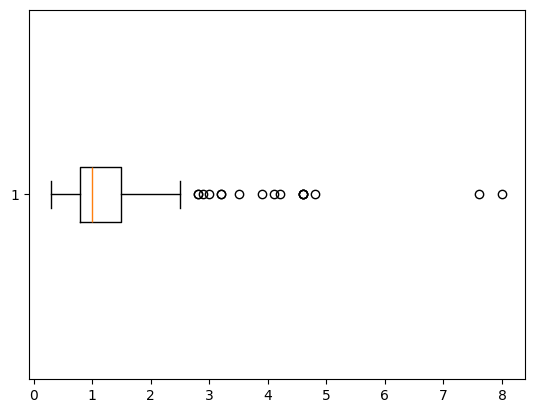

In [289]:
plt.boxplot(df_1['bilirubin'], vert = False)
plt.show()

In [290]:
Q1 = df_1['bilirubin'].quantile(0.25)
Q3 = df_1['bilirubin'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_1 = df_1[(df_1['bilirubin'] >= lower_bound) & (df_1['bilirubin'] <= upper_bound)]

In [291]:
Q1 = df_1['alk_phosphate'].quantile(0.25)
Q3 = df_1['alk_phosphate'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_1 = df_1[(df_1['alk_phosphate'] >= lower_bound) & (df_1['alk_phosphate'] <= upper_bound)]

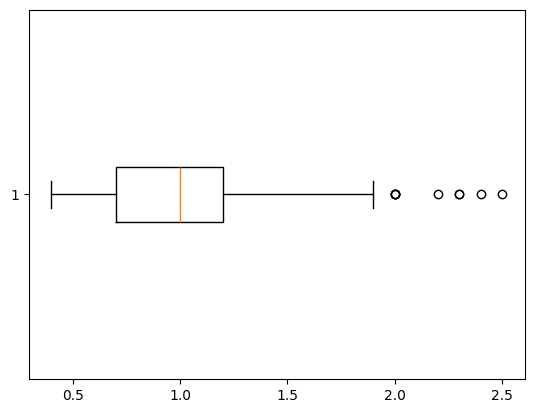

In [292]:
plt.boxplot(df_1['bilirubin'], vert = False)
plt.show()

In [293]:
cat_col = df_1.select_dtypes(include = ['str','object','bool']).columns
cat_col

Index(['sex', 'steroid', 'antivirals', 'fatigue', 'malaise', 'anorexia',
       'liver_big', 'liver_firm', 'spleen_palpable', 'spiders', 'ascites',
       'varices', 'histology', 'class'],
      dtype='str')

In [294]:
df_1[cat_col].nunique()

sex                2
steroid            2
antivirals         2
fatigue            2
malaise            2
anorexia           2
liver_big          2
liver_firm         2
spleen_palpable    2
spiders            2
ascites            2
varices            2
histology          2
class              2
dtype: int64

In [295]:
df_2 = pd.get_dummies(df_1, columns=['sex', 'steroid', 'antivirals', 'fatigue', 'malaise', 'anorexia',
       'liver_big', 'liver_firm', 'spleen_palpable', 'spiders', 'ascites',
       'varices', 'histology', 'class'], drop_first=True)

In [296]:
df_2.head()

,age,bilirubin,alk_phosphate,sgot,albumin,sex_male,steroid_True,antivirals_True,fatigue_True,malaise_True,anorexia_True,liver_big_True,liver_firm_True,spleen_palpable_True,spiders_True,ascites_True,varices_True,histology_True,class_live
0,30,1.0,85.0,18.0,4.0,True,False,False,False,False,False,False,False,False,False,False,False,False,True
1,50,0.9,135.0,42.0,3.5,False,False,False,True,False,False,False,False,False,False,False,False,False,True
2,78,0.7,96.0,32.0,4.0,False,True,False,True,False,False,True,False,False,False,False,False,False,True
3,31,0.7,46.0,52.0,4.0,False,True,True,False,False,False,True,False,False,False,False,False,False,True
4,34,1.0,85.0,200.0,4.0,False,True,False,False,False,False,True,False,False,False,False,False,False,True


In [297]:
bool_cols = ['sex_male', 'steroid_True','antivirals_True', 'fatigue_True', 'malaise_True', 
             'anorexia_True', 'liver_big_True','liver_firm_True', 'spleen_palpable_True', 
             'spiders_True', 'ascites_True', 'varices_True','histology_True','class_live']
df_2[bool_cols] = df_2[bool_cols].astype(int)

In [298]:
df_2.dtypes

age                       int64
bilirubin               float64
alk_phosphate           float64
sgot                    float64
albumin                 float64
sex_male                  int64
steroid_True              int64
antivirals_True           int64
fatigue_True              int64
malaise_True              int64
anorexia_True             int64
liver_big_True            int64
liver_firm_True           int64
spleen_palpable_True      int64
spiders_True              int64
ascites_True              int64
varices_True              int64
histology_True            int64
class_live                int64
dtype: object

In [299]:
df_2.head()

,age,bilirubin,alk_phosphate,sgot,albumin,sex_male,steroid_True,antivirals_True,fatigue_True,malaise_True,anorexia_True,liver_big_True,liver_firm_True,spleen_palpable_True,spiders_True,ascites_True,varices_True,histology_True,class_live
0,30,1.0,85.0,18.0,4.0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
1,50,0.9,135.0,42.0,3.5,0,0,0,1,0,0,0,0,0,0,0,0,0,1
2,78,0.7,96.0,32.0,4.0,0,1,0,1,0,0,1,0,0,0,0,0,0,1
3,31,0.7,46.0,52.0,4.0,0,1,1,0,0,0,1,0,0,0,0,0,0,1
4,34,1.0,85.0,200.0,4.0,0,1,0,0,0,0,1,0,0,0,0,0,0,1


In [300]:
X = df_2.drop(columns=['class_live'])
y = df_2['class_live']

In [301]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [302]:
std_scaler = StandardScaler()
rob_scaler = RobustScaler()

col_1 = ['age', 'albumin','alk_phosphate']
col_2 = ['bilirubin', 'sgot']

X_train[col_1] = std_scaler.fit_transform(X_train[col_1])
X_train[col_2] = rob_scaler.fit_transform(X_train[col_2])

X_test[col_1] = std_scaler.transform(X_test[col_1])
X_test[col_2] = rob_scaler.transform(X_test[col_2])

In [303]:
custom_weights = {0: 6, 1: 1}
model = LogisticRegression(class_weight=custom_weights)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{0: 6, 1: 1}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For 

In [349]:
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

print(f"Training Accuracy: {accuracy_score(y_train, train_preds)}")
print(f"Testing Accuracy: {accuracy_score(y_test, test_preds)}")

Training Accuracy: 0.9306930693069307
Testing Accuracy: 0.8461538461538461


In [304]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [305]:
accuracy_score(y_test, y_pred)

0.8461538461538461

In [306]:
confusion_matrix(y_test, y_pred)

array([[ 3,  3],
       [ 1, 19]])

In [307]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.50      0.60         6
           1       0.86      0.95      0.90        20

    accuracy                           0.85        26
   macro avg       0.81      0.72      0.75        26
weighted avg       0.84      0.85      0.83        26



In [308]:
roc_auc_score(y_test, y_prob)

0.9249999999999999

In [309]:
results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_pred
results['Probability'] = y_prob

In [310]:
errors = results[results['Actual'] != results['Predicted']]
errors.head()

,age,bilirubin,alk_phosphate,sgot,albumin,sex_male,steroid_True,antivirals_True,fatigue_True,malaise_True,...,liver_big_True,liver_firm_True,spleen_palpable_True,spiders_True,ascites_True,varices_True,histology_True,Actual,Predicted,Probability
153,1.041029,1.0,-0.276527,-0.661017,0.211545,1,0,0,1,0,...,1,0,1,1,0,1,1,1,0,0.021745
111,0.123834,-1.0,-0.888588,0.169492,-0.309578,0,0,1,1,1,...,1,0,0,1,0,0,1,0,1,0.519427
109,-0.626599,-0.6,-0.856374,0.372881,-1.699241,0,0,0,1,1,...,1,0,0,0,1,0,1,0,1,0.814500
147,2.458514,1.4,0.625456,7.966102,-2.046656,0,0,0,1,1,...,1,0,0,0,0,0,1,0,1,0.657369


In [311]:
errors[['Actual', 'Predicted', 'Probability']].tail()

,Actual,Predicted,Probability
153,1,0,0.021745
111,0,1,0.519427
109,0,1,0.814500
147,0,1,0.657369


In [339]:
y_pred_new = (y_prob > 0.7).astype(int)

In [340]:
confusion_matrix(y_test, y_pred_new)

array([[ 5,  1],
       [ 2, 18]])

In [341]:
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.71      0.83      0.77         6
           1       0.95      0.90      0.92        20

    accuracy                           0.88        26
   macro avg       0.83      0.87      0.85        26
weighted avg       0.89      0.88      0.89        26



In [315]:
df_1['class'].value_counts()

class
live    108
die      19
Name: count, dtype: int64

In [350]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42, class_weight=custom_weights)
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.","{0: 6, 1: 1}"
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [351]:
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

In [352]:
accuracy_score(y_test, y_pred_svm)

0.8076923076923077

In [353]:
confusion_matrix(y_test, y_pred_svm)

array([[ 2,  4],
       [ 1, 19]])

In [354]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.67      0.33      0.44         6
           1       0.83      0.95      0.88        20

    accuracy                           0.81        26
   macro avg       0.75      0.64      0.66        26
weighted avg       0.79      0.81      0.78        26

